In [1]:
%load_ext autoreload
%autoreload 2

import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import gsw
# import regionate
import cartopy.crs as ccrs
# import CM4Xutils #needed to run pip install nc-time-axis
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
import cartopy.feature as cfeature
import warnings
# from numpy import RankWarning
import cmocean as cm
warnings.filterwarnings('ignore')
import xesmf as xe
from meridional_streamfunction import * 

In [2]:
from dask_jobqueue import SLURMCluster  # setup dask cluster 
from dask.distributed import Client

log_directory="/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/WaterMassBudgets/logs"

cluster = SLURMCluster(
    cores=36,
    processes=1,
    memory='190GB',
    walltime='03:00:00',
    queue='compute',
    interface='ib0', 
log_directory = log_directory)
print(cluster.job_script())
cluster.scale(jobs=8)

client = Client(cluster)
client

#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -e /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/WaterMassBudgets/logs/dask-worker-%J.err
#SBATCH -o /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/WaterMassBudgets/logs/dask-worker-%J.out
#SBATCH -p compute
#SBATCH -n 1
#SBATCH --cpus-per-task=36
#SBATCH --mem=177G
#SBATCH -t 03:00:00

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter3/bin/python -m distributed.cli.dask_worker tcp://172.16.3.53:37569 --name dummy-name --nthreads 36 --memory-limit 176.95GiB --nanny --death-timeout 60 --interface ib0



Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.16.3.53:37569,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [3]:
datadir = lambda x="" : "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/budget_sigma2_v1.2.0/" + x

datafiles = glob.glob(datadir("CM4Xp125*"))[20:]
datafiles = sorted(datafiles)
get_transports = lambda ds: ds[["umo", "vmo", "thkcello", "sigma2_i", "zos"]]


In [4]:
import cmip_basins.cmip6 as cmip6_basins
from cmip_basins.basins import generate_basin_codes

ds = xr.open_mfdataset(
    datafiles[0:3],
    data_vars="minimal",
    coords="minimal",
    compat="override",
    parallel=True,
    preprocess = get_transports, 
    engine="zarr")

codes = generate_basin_codes(ds, lon="geolon", lat="geolat", persian=True, style="cmip6")


In [4]:
import cmip_basins.cmip6 as cmip6_basins
from cmip_basins.basins import generate_basin_codes


psis = []

for (t, file) in enumerate(datafiles): 
    print(file)
    ds = xr.open_mfdataset(
        file,
        data_vars="minimal",
        coords="minimal",
        compat="override",
        parallel=True,
        preprocess = get_transports, 
        engine="zarr")
    codes = generate_basin_codes(ds, lon="geolon", lat="geolat", persian=True, style="cmip6")

    so_ind_pac_mask = codes.isin([1, 3, 5, 10, 11])
    so_ind_pac_mask = so_ind_pac_mask.where(so_ind_pac_mask > 0.0)
    
    grid = CM4Xutils.ds_to_grid(ds, Zprefix="sigma2")
    
    c_mask = so_ind_pac_mask.where(ds.wet > 0.0)
    v_mask = grid.interp(so_ind_pac_mask, axis="Y", boundary = "extend").where(ds.wet_v > 0.0)

    ds_ind_pac = 1 * ds 
    ds_ind_pac["thkcello"] = ds_ind_pac["thkcello"].where(c_mask > 0.0)
    ds_ind_pac["zos"] = ds_ind_pac["zos"].where(c_mask > 0.0)
    ds_ind_pac["wet"] = ds_ind_pac["wet"].where(c_mask > 0.0)
    ds_ind_pac["vmo"] = ds_ind_pac["vmo"].where(v_mask > 0.0)
    ds_ind_pac["wet_v"] = ds_ind_pac["wet_v"].where(v_mask > 0.0)
    
    lats = np.arange(-75, 60, 1)
    avg_year = ds.time.dt.year.mean().item()
    psi = get_psi_mean_convergence(ds_ind_pac, lats).expand_dims(time=[avg_year])
    psis += [psi.compute()]

/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/budget_sigma2_v1.2.0/CM4Xp125_budgets_sigma2_1850-1854.zarr
/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/budget_sigma2_v1.2.0/CM4Xp125_budgets_sigma2_1855-1859.zarr
/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/budget_sigma2_v1.2.0/CM4Xp125_budgets_sigma2_1860-1864.zarr
/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/budget_sigma2_v1.2.0/CM4Xp125_budgets_sigma2_1865-1869.zarr
/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/budget_sigma2_v1.2.0/CM4Xp125_budgets_sigma2_1870-1874.zarr
/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/budget_sigma2_v1.2.0/CM4Xp125_budgets_sigma2_1875-1879.zarr
/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/budget_sigma2_v1.2.0/CM4Xp125_budgets_sigma2_1880-1884.zarr
/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/budget_sigma2_v1.2.0/CM4Xp125_budgets_sigma2_1885-1889.zarr
/vortexf

In [5]:
psis_ds = xr.concat(psis, dim = "time").sortby("time")

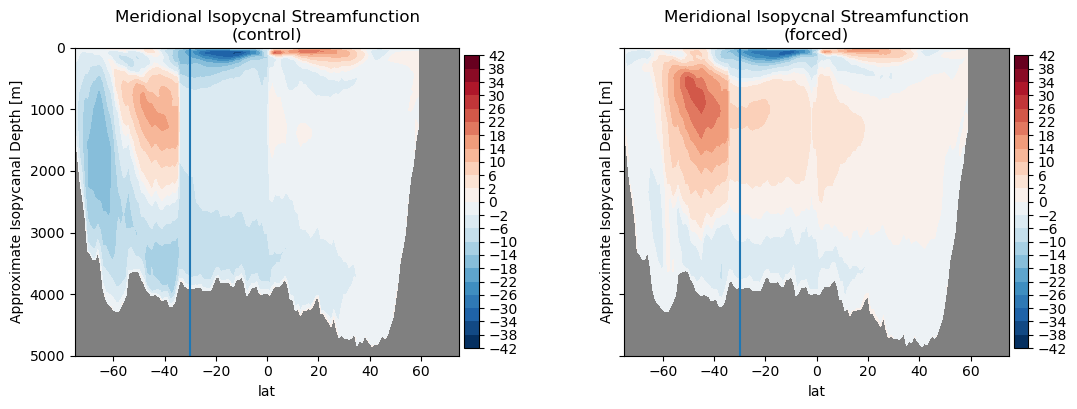

In [38]:
#define streamfunction levels
def plot_psi(fig, ax, psi): 
    levels = [-42, -38, -34, -30, -26, -22, -18, -14, -10, -6, -2, 0,   2,   6,  10,  14,  18,  22,  26,  30,  34,  38,  42]
    p1 = psi.plot.contourf(
        ax=ax, x="lat", y="depth", levels=levels,
        add_colorbar=False, cmap='RdBu_r'
    )
    c1 = fig.colorbar(p1, ax=ax, pad=0.01, spacing='uniform',
                      extend='both', shrink=0.95, orientation='vertical')
    c1.set_ticks(levels)
    c1.ax.tick_params(labelsize=10)
    ax.set_facecolor('gray')
    ax.set_xlim(-75, 75)
    ax.set_ylim(0, 5000)
    ax.invert_yaxis()
    ax.set_ylabel("Approximate Isopycanal Depth [m]")

# create one figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

# first subplot: control
ax = axes[0]
exp = "control"
psids = psis_ds.sel(exp=exp).fillna(0.0).mean("time")

psi_new = psids["psi"].fillna(0.0)
psi_new.coords["depth"] = psids["depth"]
plot_psi(fig, ax, psi_new.fillna(0.0))
ax.set_title(f"Meridional Isopycnal Streamfunction\n(control)")
ax.axvline(-30)
# # first subplot: forced
exp = "forced"
psids = psis_ds.sel(exp=exp).fillna(0.0).sel(time = slice(2090, None)).mean("time")
ax = axes[1]
psi_new = psids["psi"].fillna(0.0)
psi_new.coords["depth"] = psids["depth"]
plot_psi(fig, ax, psi_new.fillna(0.0))
ax.set_title(f"Meridional Isopycnal Streamfunction\n(forced)")
ax.axvline(-30)

In [9]:
savedir = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/"
psis_ds.to_zarr(savedir + "IndoPacIsopycnalOverturning.zarr", mode = "w")